# Data Preparation

# Imports


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import joblib


## Importar dataset

In [13]:
# Carregar o arquivo CSV com o separador correto
dados = pd.read_csv('./data/consumo-total-nacional.csv', sep=';')

In [14]:
# Mostrar as 5 primeiras linhas
dados.head()

,Data/Hora,Dia,Mês,Ano,Data,Hora,Baixa Tensão (kWh),Média Tensão (kWh),Alta Tensão (kWh),Muito Alta Tensão (kWh),Total (kWh)
0,2023-01-01T22:15:00+00:00,1,1,2023,2023-01-01,22:15,934966.149023,234136.3805,140936.7507,28769.2315,1.338809e+06
1,2023-01-02T12:30:00+00:00,2,1,2023,2023-01-02,12:30,931941.896037,459171.1502,156169.5423,46683.1650,1.593966e+06
2,2023-01-03T12:45:00+00:00,3,1,2023,2023-01-03,12:45,926626.792231,527916.3406,183103.3727,78441.4873,1.716088e+06
3,2023-01-03T15:30:00+00:00,3,1,2023,2023-01-03,15:30,853390.794825,609471.3120,190925.5341,63209.5923,1.716997e+06
4,2023-01-04T05:45:00+00:00,4,1,2023,2023-01-04,05:45,594574.803860,378070.2200,185437.9885,84820.2462,1.242903e+06


## Verificação de Distribuição dos Dados

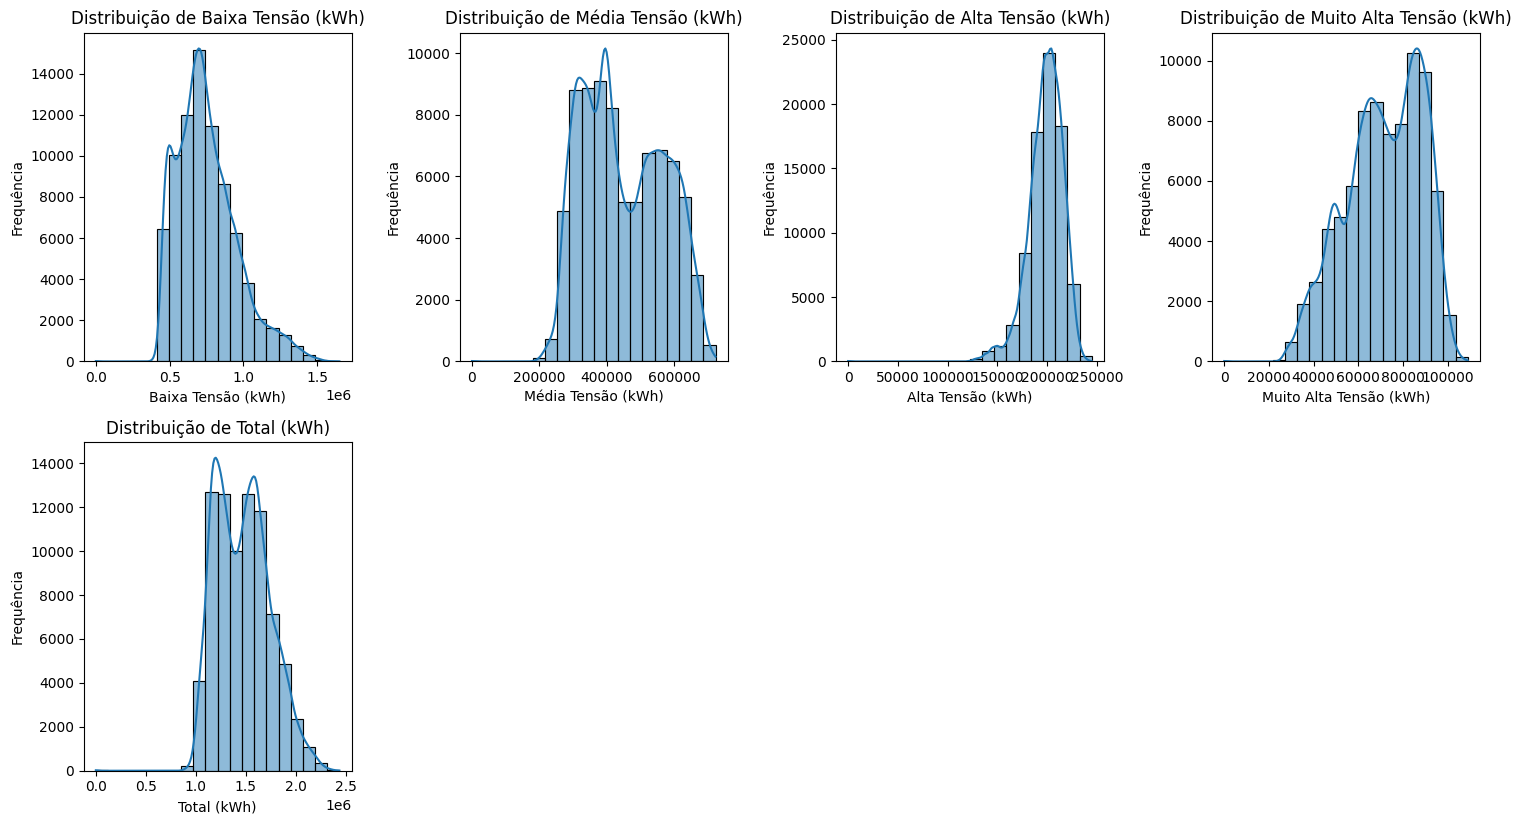

                Dia           Mês           Ano  Baixa Tensão (kWh)  \
count  79881.000000  79881.000000  79881.000000        7.988100e+04   
mean      15.588939      5.997972   2023.682691        7.537096e+05   
std        8.813927      3.542721      0.677802        2.048493e+05   
min        1.000000      1.000000   2023.000000        0.000000e+00   
25%        8.000000      3.000000   2023.000000        6.043572e+05   
50%       16.000000      6.000000   2024.000000        7.222249e+05   
75%       23.000000      9.000000   2024.000000        8.688967e+05   
max       31.000000     12.000000   2025.000000        1.651713e+06   

       Média Tensão (kWh)  Alta Tensão (kWh)  Muito Alta Tensão (kWh)  \
count        79881.000000       79881.000000             79881.000000   
mean        449998.319417      198700.015723             71473.624225   
std         119502.373789       17308.653935             16878.706802   
min              0.000000           0.000000                 0.00000

In [15]:
plt.figure(figsize=(15, 12))

# Criando histogramas para as variáveis de consumo de energia
for i, column in enumerate(dados.columns[6:], 1):  # Ignora a primeira coluna "Data/Hora"
    plt.subplot(3, 4, i)  # Alterado para 3 linhas e 4 colunas
    sns.histplot(dados[column], kde=True, bins=20)
    plt.title(f'Distribuição de {column}')
    plt.xlabel(column)
    plt.ylabel('Frequência')

plt.tight_layout()  # Ajusta o layout para que os gráficos não se sobreponham
plt.show()

# Cálculo de estatísticas descritivas (média, desvio padrão, etc.)
desc_stats = dados.describe()
print(desc_stats)



## Análise de Outliers


In [16]:
# Análise de outliers usando o método IQR
outliers = {}

for column in dados.columns[5:]:  # Excluindo as colunas "Data/Hora", "Dia", "Mês", "Ano", "Data"
    # Verificar se a coluna é numérica antes de calcular os percentis
    if dados[column].dtype in ['float64', 'int64']:  # Garantir que estamos lidando com dados numéricos
        Q1 = dados[column].quantile(0.25)  # Primeiro quartil
        Q3 = dados[column].quantile(0.75)  # Terceiro quartil
        IQR = Q3 - Q1  # Intervalo Interquartil
        
        # Definindo os limites para detectar outliers
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Identificando os outliers
        outliers[column] = dados[(dados[column] < lower_bound) | (dados[column] > upper_bound)]
        
        # Exibindo os limites
        print(f"Outliers para {column}:")
        print(f"Limite inferior: {lower_bound}")
        print(f"Limite superior: {upper_bound}")
        print(f"Número de outliers: {outliers[column].shape[0]}")
        print("-" * 40)

# Opcional: Mostrar exemplos de outliers encontrados
for column, outlier_data in outliers.items():
    if outlier_data.shape[0] > 0:
        print(f"Exemplos de outliers para {column}:")
        print(outlier_data.head())  # Mostra os primeiros exemplos de outliers
        print("-" * 40)


Outliers para Baixa Tensão (kWh):
Limite inferior: 207547.88515949994
Limite superior: 1265705.9680915
Número de outliers: 1991
----------------------------------------
Outliers para Média Tensão (kWh):
Limite inferior: 37719.61149999994
Limite superior: 862918.8035
Número de outliers: 12
----------------------------------------
Outliers para Alta Tensão (kWh):
Limite inferior: 156153.81115000002
Limite superior: 243530.60275000002
Número de outliers: 1852
----------------------------------------
Outliers para Muito Alta Tensão (kWh):
Limite inferior: 20923.992749999998
Limite superior: 124398.57235
Número de outliers: 12
----------------------------------------
Outliers para Total (kWh):
Limite inferior: 626871.8971585
Limite superior: 2276472.4530665
Número de outliers: 110
----------------------------------------
Exemplos de outliers para Baixa Tensão (kWh):
                     Data/Hora  Dia  Mês   Ano        Data   Hora  \
20   2023-01-19T20:45:00+00:00   19    1  2023  2023-01-1

## Correlações

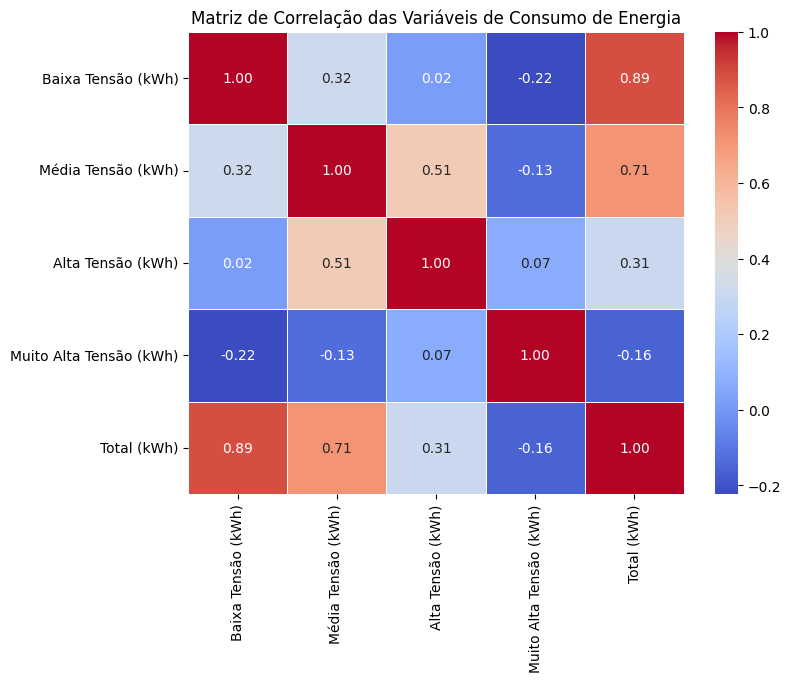

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# Selecionar apenas as colunas numéricas (ignorando "Data/Hora", "Dia", "Mês", "Ano", "Data", "Hora")
dados_numericos = dados.drop(columns=['Data/Hora', 'Dia', 'Mês', 'Ano', 'Data', 'Hora'])

# Calcular a matriz de correlação
correlation_matrix = dados_numericos.corr()

# Visualizar a matriz de correlação com um gráfico de calor (heatmap)
plt.figure(figsize=(8, 6))  # Tamanho da figura
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlação das Variáveis de Consumo de Energia')
plt.show()


Principais observações:

* Baixa Tensão tem correlação muito forte com o Total (0.89), indicando que o **consumo em Baixa Tensão representa grande parte do consumo total de energia**.
* Média Tensão também tem correlação forte com o Total (0.71), sendo o **segundo maior contribuinte para o consumo total**.
* Alta Tensão tem correlação positiva moderada com o Total (0.31) e com a Média Tensão (0.51).
* Muito Alta Tensão apresenta correlações negativas com Baixa Tensão (-0.22), Média Tensão (-0.13) e com o Total (-0.16), sugerindo que quando o consumo em Muito Alta Tensão aumenta, tende a haver uma redução nos outros tipos de consumo, especialmente em Baixa Tensão.
* A Baixa Tensão e a Média Tensão apresentam correlação positiva fraca entre si (0.32).
* A correlação entre Baixa Tensão e Alta Tensão é praticamente inexistente (0.02).

Estas correlações sugerem que o consumo energético é dominado pelos consumidores de Baixa e Média Tensão, enquanto o consumo em Muito Alta Tensão parece seguir um padrão diferente e inversamente relacionado com os demais.

## Valores Ausentes

In [18]:
dados.isnull().sum()

Data/Hora                  0
Dia                        0
Mês                        0
Ano                        0
Data                       0
Hora                       0
Baixa Tensão (kWh)         0
Média Tensão (kWh)         0
Alta Tensão (kWh)          0
Muito Alta Tensão (kWh)    0
Total (kWh)                0
dtype: int64

## Normalização

In [19]:
colunas_para_normalizar = [
    'Baixa Tensão (kWh)',
    'Média Tensão (kWh)',
    'Alta Tensão (kWh)',
    'Muito Alta Tensão (kWh)',
    'Total (kWh)'
]


# Criar o scaler
scaler = MinMaxScaler()

# Ajustar e transformar
dados[colunas_para_normalizar] = scaler.fit_transform(dados[colunas_para_normalizar])

joblib.dump(scaler, 'scaler.pkl')
dados[colunas_para_normalizar].describe()

# Guardar os dados normalizados num novo CSV
dados.to_csv('data/consumo-total-nacional-normalizado.csv', sep=';', index=True)



## Identificação de Padrões
### Verificar Estacionariedade

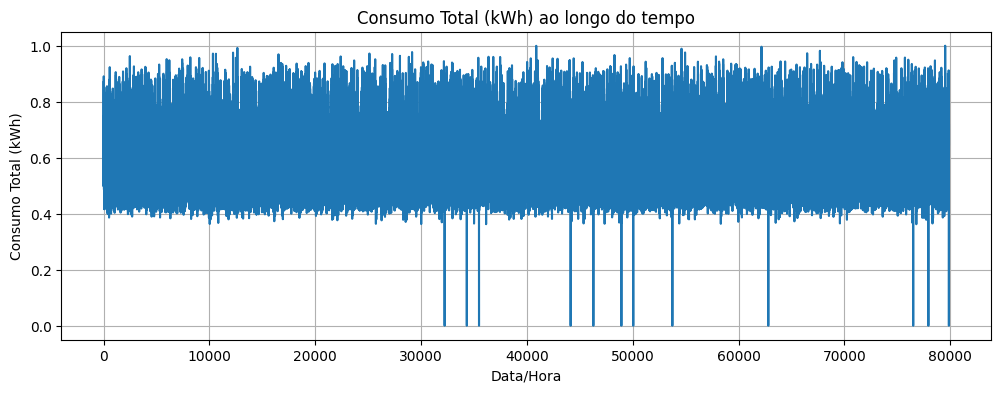

Estatística ADF: -30.105022205463346
p-valor: 0.0


In [20]:
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

# Plot da série temporal
dados["Total (kWh)"].plot(figsize=(12, 4), title="Consumo Total (kWh) ao longo do tempo")
plt.xlabel("Data/Hora")
plt.ylabel("Consumo Total (kWh)")
plt.grid()
plt.show()

# Teste de estacionariedade (ADF)
resultado = adfuller(dados["Total (kWh)"].dropna())
print("Estatística ADF:", resultado[0])
print("p-valor:", resultado[1])


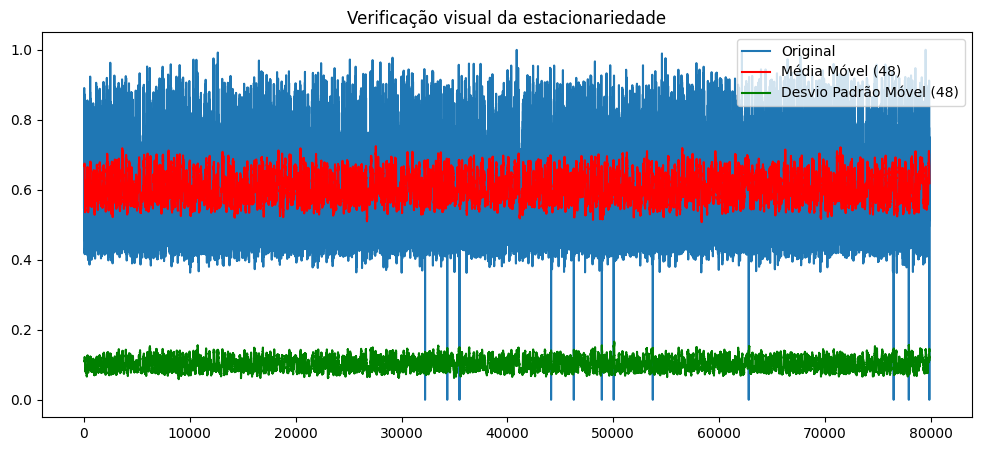

In [21]:
# Média móvel e desvio padrão ao longo do tempo
rolling_mean = dados["Total (kWh)"].rolling(window=48).mean()
rolling_std = dados["Total (kWh)"].rolling(window=48).std()

plt.figure(figsize=(12, 5))
plt.plot(dados["Total (kWh)"], label="Original")
plt.plot(rolling_mean, label="Média Móvel (48)", color='red')
plt.plot(rolling_std, label="Desvio Padrão Móvel (48)", color='green')
plt.legend()
plt.title("Verificação visual da estacionariedade")
plt.show()


A série é estacionária.